In [1]:
# -----------------------------
# Imports 
# -----------------------------
from pathlib import Path
from datetime import datetime, timezone
import requests
from tqdm import tqdm
import xml.etree.ElementTree as ET

import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

import cfgrib
import copernicusmarine
import shutil
import cdsapi
import zipfile



In [2]:
# -----------------------------
# Optional: install required packages (run once if missing)
# -----------------------------
# !pip install --user requests tqdm xarray pandas matplotlib cartopy cfgrib eccodes copernicusmarine h5py cdsapi


In [3]:
"""
One-time download of the latest HARMONIE (MEPS) surface wind from FMI Open Data.

- Area: Archipelago Sea
- Format: NetCDF
- Forecast length: 48 hours (hourly)
- Full spatial resolution
- Format: netCDF
"""

# -----------------------------
# User-defined settings
# -----------------------------

OUTDIR = Path("data")
OUTDIR.mkdir(exist_ok=True)

# Forecast domain
BBOX = "20.4,59.7,22.9,60.5"  # lon_min,lat_min,lon_max,lat_max

# Common parameters
COMMON_PARAMS = {
    "bbox": BBOX,
    "format": "netcdf",
    "projection": "EPSG:4326",
    "timestep": "60",     # minutes
    "timesteps": "48",    # 48-hour forecast
    # Removed gridstep to get full spatial resolution
}

# -----------------------------
# HARMONIE wind download
# -----------------------------
harmonie_params = COMMON_PARAMS.copy()
harmonie_params.update({
    "producer": "harmonie_scandinavia_surface",
    "param": "windums,windvms",
})

harmonie_query = "&".join(f"{k}={v}" for k, v in harmonie_params.items())
harmonie_url = f"https://opendata.fmi.fi/download?{harmonie_query}"

outfile_wind = OUTDIR / "harmonie_wind_latest_48h.nc"
print(f"\nDownloading HARMONIE wind forecast to: {outfile_wind}")

with requests.get(harmonie_url, stream=True, timeout=300) as r:
    r.raise_for_status()
    total_size = int(r.headers.get('content-length', 0))
    chunk_size = 8192
    with open(outfile_wind, 'wb') as f, tqdm(
        total=total_size, unit='B', unit_scale=True, desc="HARMONIE wind"
    ) as pbar:
        for chunk in r.iter_content(chunk_size=chunk_size):
            if chunk:
                f.write(chunk)
                pbar.update(len(chunk))
print("HARMONIE wind download complete.")

# Display wind dataset
wind_ds = xr.open_dataset("data/harmonie_wind_latest_48h.nc")
print(wind_ds)

HARMONIE wind: 1.55MB [00:01, 1.19MB/s]


HARMONIE wind download complete.
<xarray.Dataset> Size: 2MB
Dimensions:            (time: 48, lat: 36, lon: 112)
Coordinates:
  * time               (time) datetime64[ns] 384B 2026-03-24T03:00:00 ... 202...
  * lat                (lat) float32 144B 59.7 59.72 59.75 ... 60.45 60.48 60.5
  * lon                (lon) float32 448B 20.4 20.42 20.45 ... 22.85 22.88 22.9
Data variables:
    crs                int16 2B ...
    eastward_wind_23   (time, lat, lon) float32 774kB ...
    northward_wind_24  (time, lat, lon) float32 774kB ...
Attributes:
    Conventions:  CF-1.6
    title:        <title>
    institution:  fmi.fi
    source:       <producer>


In [4]:
"""
One-time download of the latest WAM wave forecast from FMI Open Data

- Area: Archipelago Sea
- Format: GRIB2
- Forecast length: 48 hours (hourly)
"""

# -----------------------------
# User can set origintime here (UTC)
# Format: "YYYY-MM-DDTHH:MM:SSZ", e.g., "2026-01-26T06:00:00Z"
# If None, use latest 00/06/12/18 UTC run
# -----------------------------

USER_ORIGINTIME = 'NONE'

# Output directory
OUTDIR = Path("data")
OUTDIR.mkdir(exist_ok=True)

# Bounding box: Archipelago Sea
BBOX = "20.4,59.7,22.9,60.5"

# -----------------------------
# Determine origintime
# -----------------------------
now = datetime.now(timezone.utc)
if USER_ORIGINTIME is not None:
    origintime_str = USER_ORIGINTIME
else:
    run_hour = (now.hour // 6) * 6
    origintime = now.replace(hour=run_hour, minute=0, second=0, microsecond=0)
    origintime_str = origintime.isoformat().replace("+00:00", "Z")

print(f"Using WAM origintime: {origintime_str}")

# Create filename that encodes origintime
origintime_clean = origintime_str.replace(":", "").replace("-", "")
outfile = OUTDIR / f"wam_{origintime_clean}_48h.grib2"

# -----------------------------
# Download WAM data if not already present
# -----------------------------
if not outfile.exists():
    print(f"Downloading WAM data to {outfile} ...")

    WFS_URL = "https://opendata.fmi.fi/wfs"
    params = {
        "service": "WFS",
        "version": "2.0.0",
        "request": "GetFeature",
        "storedquery_id": "fmi::forecast::wam::grid",
        "bbox": BBOX,
        "origintime": origintime_str,
    }

    r = requests.get(WFS_URL, params=params, timeout=300)
    r.raise_for_status()

    root = ET.fromstring(r.text)
    ns = {"gml": "http://www.opengis.net/gml/3.2",
          "om": "http://www.opengis.net/om/2.0"}

    file_ref = root.find(".//gml:fileReference", ns)
    if file_ref is None:
        raise RuntimeError("No WAM download link found")

    download_url = file_ref.text
    print("Download URL:", download_url)

    with requests.get(download_url, stream=True, timeout=600) as r:
        r.raise_for_status()
        total_size = int(r.headers.get("content-length", 0))
        chunk_size = 8192

        with open(outfile, "wb") as f, tqdm(
            total=total_size, unit="B", unit_scale=True, desc="WAM waves"
        ) as pbar:
            for chunk in r.iter_content(chunk_size=chunk_size):
                if chunk:
                    f.write(chunk)
                    pbar.update(len(chunk))
    print("Download complete.")
else:
    print(f"File already exists: {outfile}")

# -----------------------------
# Load WAM dataset
# -----------------------------
wam_ds = xr.open_dataset(outfile, engine="cfgrib")
print("WAM origintime in file:", wam_ds.attrs.get("GRIB_referenceTime"))
print(wam_ds)


Using WAM origintime: NONE
File already exists: data/wam_NONE_48h.grib2
WAM origintime in file: None
<xarray.Dataset> Size: 5MB
Dimensions:            (step: 61, latitude: 47, longitude: 147)
Coordinates:
  * step               (step) timedelta64[ns] 488B 06:00:00 ... 2 days 18:00:00
  * latitude           (latitude) float64 376B 59.7 59.72 59.73 ... 60.48 60.5
  * longitude          (longitude) float64 1kB 20.4 20.42 20.43 ... 22.88 22.9
    time               datetime64[ns] 8B ...
    heightAboveGround  float64 8B ...
    valid_time         (step) datetime64[ns] 488B ...
    entireAtmosphere   float64 8B ...
Data variables:
    swh                (step, latitude, longitude) float32 2MB ...
    mwd                (step, latitude, longitude) float32 2MB ...
    shts               (step, latitude, longitude) float32 2MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB

Ignoring index file 'data/wam_wave_latest_48h.grib2.5b7b6.idx' older than GRIB file


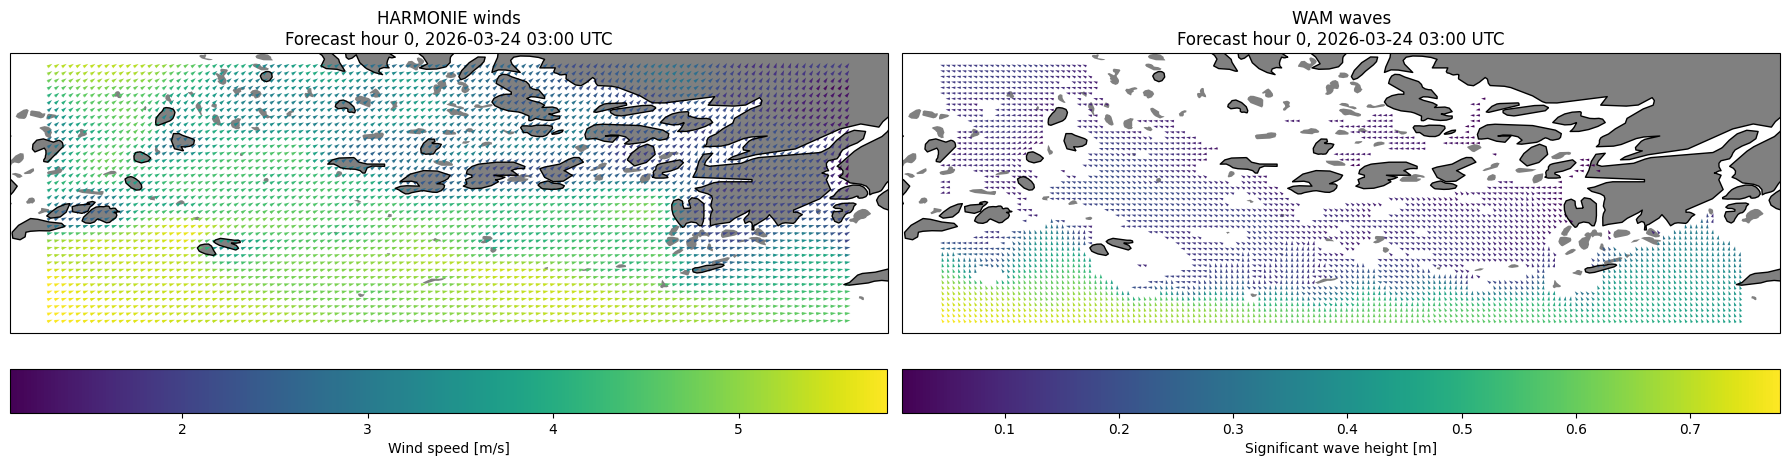

In [5]:
""" 
Plot HARMONIE and WAM forecasts
"""

# -----------------------------
# Load datasets
# -----------------------------
ds = xr.open_dataset("data/harmonie_wind_latest_48h.nc")
ds_wam = xr.open_dataset("data/wam_wave_latest_48h.grib2", engine="cfgrib")

hour = 0  # forecast hour index
ds_slice = ds.isel(time=hour)
forecast_time = pd.to_datetime(ds_slice['time'].values)

# WAM slice at same forecast hour
ds_wam_slice = ds_wam.isel(step=hour)

# -----------------------------
# Create figure with 2 stacked subplots
# -----------------------------
fig, axes = plt.subplots(
    1, 2, figsize=(18, 18),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

# -----------------------------
# Panel 1: HARMONIE winds (arrows sized to grid)
# -----------------------------
ax = axes[0]
ax.add_feature(cfeature.LAND, facecolor='gray')
ax.add_feature(cfeature.COASTLINE)

# Extract wind components and coordinates
u_wind = ds_slice['eastward_wind_23'].values
v_wind = ds_slice['northward_wind_24'].values
lon_wind = ds_slice['lon'].values
lat_wind = ds_slice['lat'].values

# Normalize to unit vectors (all arrows same length)
norm = np.sqrt(u_wind**2 + v_wind**2)
u_unit = u_wind / norm
v_unit = v_wind / norm

# Compute grid spacing from 1D coordinates
dx = np.mean(np.diff(lon_wind))
dy = np.mean(np.diff(lat_wind))
arrow_length = min(dx, dy) * 0.8

# Scale vectors to grid spacing
u_plot = u_unit * arrow_length
v_plot = v_unit * arrow_length

# Create 2D coordinates for quiver
lon2d, lat2d = np.meshgrid(lon_wind, lat_wind)

# Quiver plot
q = ax.quiver(
    lon2d, lat2d, u_plot, v_plot, np.sqrt(u_wind**2 + v_wind**2),  # color by wind speed
    angles='xy', scale_units='xy', scale=1,
    cmap='viridis', pivot='middle', width=0.003
)

# Colorbar for wind speed
cbar = fig.colorbar(q, ax=ax, orientation='horizontal', pad=0.02)
cbar.set_label('Wind speed [m/s]')

ax.set_title(f"HARMONIE winds\nForecast hour {hour}, {forecast_time:%Y-%m-%d %H:%M UTC}")

# -----------------------------
# Panel 2: WAM waves (direction & height, arrows sized to grid)
# -----------------------------
ax = axes[1]
ax.add_feature(cfeature.LAND, facecolor='gray')
ax.add_feature(cfeature.COASTLINE)

# Extract WAM variables
swh = ds_wam_slice['swh'].values
mwd = ds_wam_slice['mwd'].values
lon = ds_wam_slice['longitude'].values
lat = ds_wam_slice['latitude'].values

# Convert wave direction to radians (toward propagation)
angle_rad = np.deg2rad((mwd + 180) % 360)
u = np.sin(angle_rad)
v = np.cos(angle_rad)

# Normalize to unit vectors
norm = np.sqrt(u**2 + v**2)
u_unit = u / norm
v_unit = v / norm

# Grid spacing
dx = np.mean(np.diff(lon))
dy = np.mean(np.diff(lat))
arrow_length = min(dx, dy) * 0.8

# Scale vectors
u_plot = u_unit * arrow_length
v_plot = v_unit * arrow_length

# 2D coordinates
lon2d, lat2d = np.meshgrid(lon, lat)

# Quiver plot: arrows show direction, color shows swh
q = ax.quiver(
    lon2d, lat2d, u_plot, v_plot, swh,
    angles='xy', scale_units='xy', scale=1,
    cmap='viridis', pivot='middle', width=0.003
)

# Colorbar for wave height
cbar = fig.colorbar(q, ax=ax, orientation='horizontal', pad=0.02)
cbar.set_label('Significant wave height [m]')

ax.set_title(f"WAM waves\nForecast hour {hour}, {forecast_time:%Y-%m-%d %H:%M UTC}")

plt.tight_layout()
plt.show()
